# Comprendre le chômage en France 

Vous êtes vous déjà demandé d'où sortaient les chiffres qu'annoncent les politiques ou les medias lorsqu'ils parlent de chômage. Étant un sujet d'intérêt dans les pays occidentaux, tentons de comprendre ce qu'il se passe en terme de chômages en France. Pour cela, nous avons récupéré des données sur [data.gouv](https://www.insee.fr/fr/statistiques/3555153#consulter). Elles représentent les données du chômage en France en 2017.



## Documentation du dataset 

Regarder la documentation du dataset [ici](https://www.insee.fr/fr/statistiques/3555153#documentation)

* Importez les librairies 
  * `pandas` 
  * `matplotlib` (et plus particulièrement le module `pyplot`)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

* Chargez le fichier `fdeec17.csv`

In [3]:
dataset = pd.read_csv('../j1-data/fdeec17.csv')
dataset.head()

,ANNEE,TRIM,CATAU2010R,METRODOM,TYPMEN7,AGE3,AGE5,COURED,ENFRED,NFRRED,...,DIP11,CSTOTPRM,IDENTM,EXTRIAN,EMPNBH,HREC,HHCE,HPLUSA,JOURTR,NBTOTE
0,2017,1,1,1,2,50,50,2,1,1.0,...,30.0,52.0,1,263.388752,37.0,NaN,37.0,NaN,5.0,NaN
1,2017,1,1,1,2,15,15,2,2,1.0,...,42.0,52.0,1,263.388752,32.0,NaN,32.0,NaN,4.0,NaN
2,2017,1,1,1,2,15,15,2,2,1.0,...,31.0,52.0,1,263.388752,38.0,NaN,38.0,NaN,5.0,NaN
3,2017,3,1,1,2,50,50,2,1,1.0,...,30.0,52.0,2,176.893923,37.0,NaN,37.0,NaN,5.0,NaN
4,2017,3,1,1,2,15,15,2,2,1.0,...,42.0,52.0,2,176.893923,40.0,NaN,32.0,NaN,4.0,NaN


* En faisant un [pie-chart](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.pie.html), montrez la part de chômeurs, d'inactifs et d'actifs occupés en France à partir de la variable ACTEU. Faites attention de faire apparaitre : 

  * Le pourcentage de chaque partie 
  * Une légende 

In [4]:
chomeurs = dataset['ACTEU'].apply(lambda x:
                                  "Actif Occupé" if x==1 
                                  else "Chômeur" if x==2
                                  else "Inactif" if x==3 
                                  else "Inconnu")

In [5]:
# autre solution
chomeurs = dataset['ACTEU'].replace({1: "Actif Occupé", 2: "Chômeur", 3: "Inactif"}).fillna("Inconnu")

In [6]:
chomeurs.unique()

array(['Actif Occupé', 'Inactif', 'Chômeur', 'Inconnu'], dtype=object)

In [7]:
pie_chart_data = chomeurs.value_counts()
pie_chart_data

Inactif         207520
Actif Occupé    198054
Chômeur          21864
Inconnu           1204
Name: ACTEU, dtype: int64

In [8]:
explode = (0.2, 0.2, 0.5, 0.1)

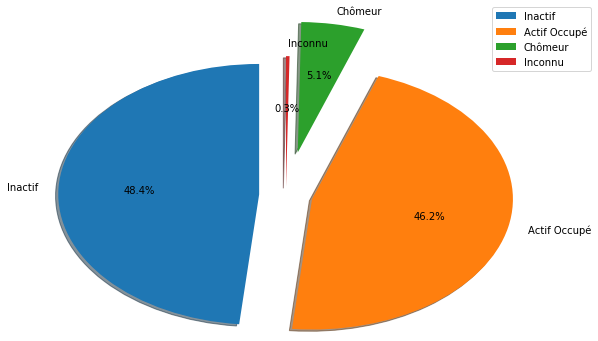

In [9]:
plt.figure()
plt.pie(
    pie_chart_data.values,
    labels=pie_chart_data.index,
    autopct='%1.1f%%',
    shadow=True, 
    startangle=90,
    explode=explode,
    radius=1.5
)
plt.legend(bbox_to_anchor=(1.1, 1.05))
plt.show()

---> Le chiffre du chômage semble bas et, si on regarde l'explication des *inactifs*, celle-ci semble inclure beaucoup de monde (étudiants, personne ne cherchant pas d'emploi etc.)

* Faites le même graphique sur la variable ACTEU6 qui est plus précise sur le type d'actifs 

In [10]:
dataset['ACTEU6'].unique()

array([ 1.,  6.,  3.,  5., nan,  4.])

In [10]:
acteu6_cat = {
    1: "Actif Occupé",
    3: "Chômeur PSERE",
    4: "Autre Chômeur BIT",
    5: "Etudiant, élève, stagiaire en formation",
    6: "Autres inactifs (dont retraité)"
}

In [11]:
chomeurs = dataset['ACTEU6'].replace(acteu6_cat).fillna("Inconnu")

In [12]:
# autre solution
chomeurs = dataset['ACTEU6'].apply(lambda x: acteu6_cat.get(x, "Inconnu"))

In [13]:
pie_chart_data = chomeurs.value_counts()
pie_chart_data

Actif Occupé                               198054
Autres inactifs (dont retraité)            172921
Etudiant, élève, stagiaire en formation     34599
Chômeur PSERE                               20854
Inconnu                                      1204
Autre Chômeur BIT                            1010
Name: ACTEU6, dtype: int64

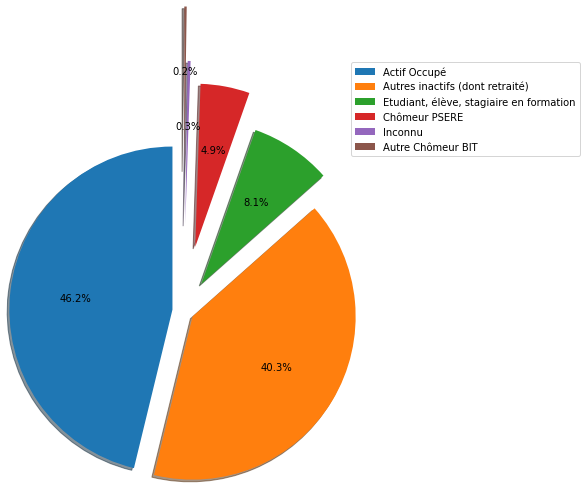

In [14]:
plt.figure(figsize = (10, 5))
plt.pie(
    pie_chart_data, 
    autopct='%1.1f%%',
    shadow=True, 
    startangle=90,
    explode=(0.1, 0.1,0.3,0.6,0.8, 1.3),
    radius=1.5 
)

plt.legend(pie_chart_data.index, bbox_to_anchor=(1.1, 1.05))
plt.show()

* En créant un [stacked bar chart](https://pythonmatplotlibtips.blogspot.com/2018/11/normalized-stacked-barplot-number-percentage-python-matplotlib.html), comparez :

  * le rapport *chômeurs* / *Actifs occupés* 
  * Le rapport *chômeurs* / (*Actifs occupés* + *Inactifs*)

In [15]:
# On recréé les données dont on a besoin 
chomeurs = dataset['ACTEU'].replace({1: "Actif Occupé", 2: "Chômeur", 3: "Inactif"}).fillna("Inconnu")
chart_data = chomeurs.value_counts()
chart_data

Inactif         207520
Actif Occupé    198054
Chômeur          21864
Inconnu           1204
Name: ACTEU, dtype: int64

In [16]:
# On créé le rapport chômeurs / Actifs occupés et le rapport Chômeurs / (Actifs occupés + Inactifs)
chom_actif = chart_data['Chômeur'] / chart_data['Actif Occupé']
chom_actif_inactif = chart_data['Chômeur'] / (chart_data['Actif Occupé'] + chart_data['Inactif'])

data_chom = [chom_actif, chom_actif_inactif]
print(f"Rapports de chômeurs:\n {data_chom}")

Rapports de chômeurs:
 [0.11039413493289708, 0.05390878113488537]


In [17]:
# Pour la suite, on calcule le complémentaire des 2 rapports précédents
data_actifs = []
for ratio in data_chom:
    data_actifs.append(1 - ratio)

print(f"Rapports d'actifs:\n {data_actifs}")

Rapports d'actifs:
 [0.8896058650671029, 0.9460912188651146]


In [18]:
# On créé une liste legend qui contiendra les deux categories : 
## chômeurs / Actifs occupés
## Chômeurs / (Actifs occupés + Inactifs)
legend = ["Chômeurs / Actifs Occupés", "Chômeurs / Actifs + Inactifs"]
legend

['Chômeurs / Actifs Occupés', 'Chômeurs / Actifs + Inactifs']

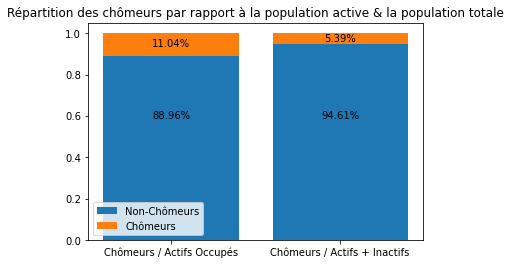

In [19]:
# On créé deux bar charts qui seront superposés l'un à l'autre
## N'oubliez pas d'utiliser deux plt.bar()
## Pour créer les légendes, on peut utiliser plt.text()
## Pour créer un titre, on peut utiliser plt.set_title()

plt.figure()
plt.bar(legend, data_actifs, label="Non-Chômeurs")
plt.bar(legend, data_chom, bottom=data_actifs, label="Chômeurs")

plt.text(legend[0], 0.6, f"{data_actifs[0]:.2%}", ha="center", va="center")
plt.text(legend[0], 0.95, f"{data_chom[0]:.2%}", ha="center", va="center")

plt.text(legend[1], 0.6, f"{data_actifs[1]:.2%}", ha="center", va="center")
plt.text(legend[1], 0.975, f"{data_chom[1]:.2%}", ha="center", va="center")

plt.legend()
plt.title("Répartition des chômeurs par rapport à la population active & la population totale")

plt.show()

Il semblerait que le chômage représentait 11% de la population active (travailleuse) en France en 2017 selon le BIT

* En créant à nouveau un [*bar chart*](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.bar.html), regardez cette fois la répartition de l'ancienneté du chômage. Le nom de la variable est ANCCHOM

In [30]:
dataset['ANCCHOM'].unique()

array([nan,  2.,  3.,  4.,  1.,  8.,  7.,  5.,  6.])

In [31]:
# On renomme les catégories de notre colonne 
ancchom_cat = {
    1: "Moins d'un mois",
    2: "De 1 mois à moins de 3 mois",
    3: "De 3 mois à moins de 6 mois",
    4: "De 6 mois à moins d'un an",
    5: "De 1 an à moins d'un an et demi",
    6: "De 1 an et demi à moins de 2 ans",
    7: "De 2 ans à moins de 3 ans",
    8: "3 ans ou plus"
}

duree_chomage = dataset['ANCCHOM'].replace(ancchom_cat)
chart_data = duree_chomage.value_counts()
chart_data

3 ans ou plus                       3906
De 6 mois à moins d'un an           3648
De 1 an à moins d'un an et demi     3398
De 1 mois à moins de 3 mois         3270
De 3 mois à moins de 6 mois         3193
De 2 ans à moins de 3 ans           2289
De 1 an et demi à moins de 2 ans    1132
Moins d'un mois                      902
Name: ANCCHOM, dtype: int64

<BarContainer object of 8 artists>

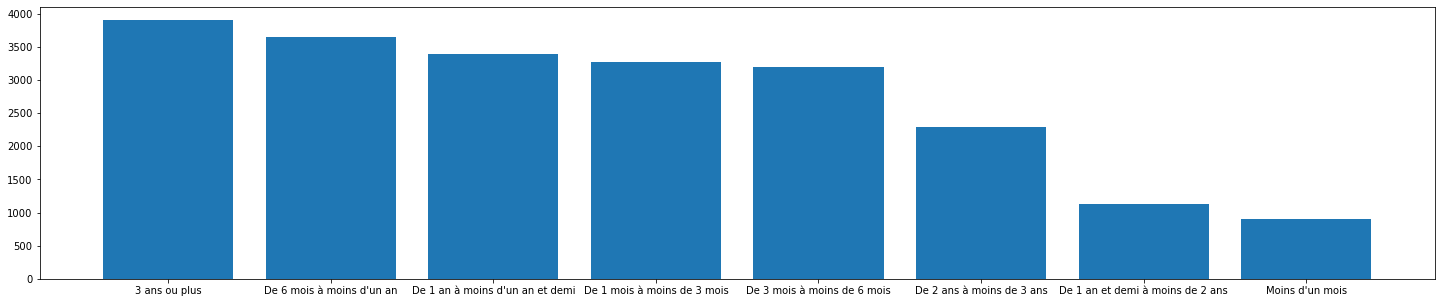

In [32]:
# On créé maintenant notre bar chart
plt.figure(figsize=(25, 5))
plt.bar(chart_data.index, chart_data.values)

* La répartition se voit assez mal sur le *bar chart*, tentez de le refaire sur un *pie chart* 

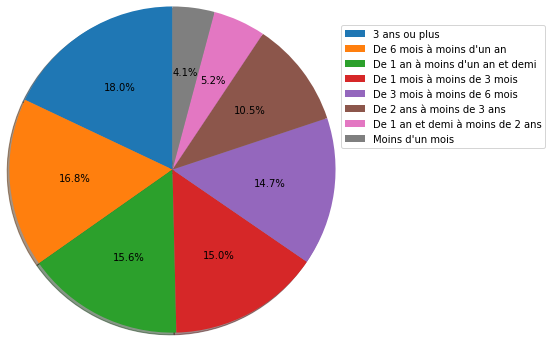

In [23]:
plt.figure(figsize=(10, 5))
plt.pie(chart_data, 
        autopct='%1.1f%%',
        shadow=True, 
        startangle=90,
        radius=1.5)
plt.legend(chart_data.index, bbox_to_anchor=(1.1, 1.05))
plt.show()

* Il serait intéressant de voir la répartition des personnes inscrites à Pôle Emploi ou dans un organisme de placement parmi ces personnes au chômage. Regardez cette répartition grâce à la colonne CONTACT 
  * Enlevez directement les NaN de votre graphique

In [24]:
# On renomme les catégories de notre colonne 
contact = dataset['CONTACT'].dropna().replace({1: "Oui", 2: "Non"})

chart_data = contact.value_counts()
chart_data

Non    15984
Oui    13144
Name: CONTACT, dtype: int64

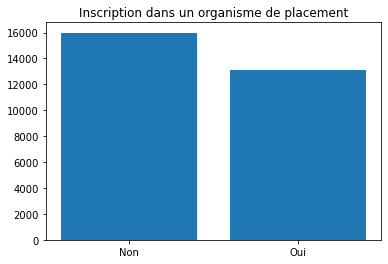

In [25]:
# On créé notre graphique 
plt.bar(chart_data.index, chart_data.values)
plt.title("Inscription dans un organisme de placement")
plt.show()

* Regardons ce qui pousse les français à changer d'emploi, grâce à la colonne CREACCP, crééz un bar chart horizontale qui va permettre de connaitre les principales raisons de changement d'emploi des français. 

In [26]:
# On renomme les catégories de notre colonne
creaccp_cat = {
    1: "Risque de perdre ou va perdre son emploi actuel (y compris fin de contrats courts)",
    2: "Désire un emploi plus intéressant",
    3: "Veut un emploi plus stable (CDI)",
    4: "Veut travailler plus d'heures",
    5: "Désire un travail avec un rythme horaire plus adapté ou plus modulable",
    6: "Désire des conditions de travail moins pénibles ou plus adaptées à sa santé",
    7: "Désire augmenter ses revenus",
    8: "Désire diminuer son temps de transport",
    9: "Doit ou veut déménager",
    10: "Veut s'installer à son compte",
    11: "Veut changer de métier ou de secteur",
    12: "Trouve l'ambiance de travail mauvaise, les relations de travail conflictuelles",
    13: None
}
creaccp = dataset['CREACCP'].replace(creaccp_cat)

chart_data = creaccp.value_counts(ascending=True)
chart_data

Doit ou veut déménager                                                                 216
Veut s'installer à son compte                                                          354
Désire diminuer son temps de transport                                                 598
Désire un travail avec un rythme horaire plus adapté ou plus modulable                1102
Trouve l'ambiance de travail mauvaise, les relations de travail conflictuelles        1223
Veut changer de métier ou de secteur                                                  1392
Veut travailler plus d'heures                                                         1404
Risque de perdre ou va perdre son emploi actuel (y compris fin de contrats courts)    1582
Désire des conditions de travail moins pénibles ou plus adaptées à sa santé           1820
Veut un emploi plus stable (CDI)                                                      2462
Désire un emploi plus intéressant                                                     2779

In [27]:
# Nous avons besoin de faire une répartition par pourcentage
# Calculons donc le nombre total de répondants 
s = chart_data.dropna().sum()
print(s)

21707


In [28]:
# Calculons maintenant la répartition de chacune des réponses 
repartition = chart_data.values / s
print(repartition)

[0.00995071 0.0163081  0.02754872 0.05076703 0.05634127 0.06412678
 0.0646796  0.07287972 0.08384392 0.11341963 0.12802322 0.3121113 ]


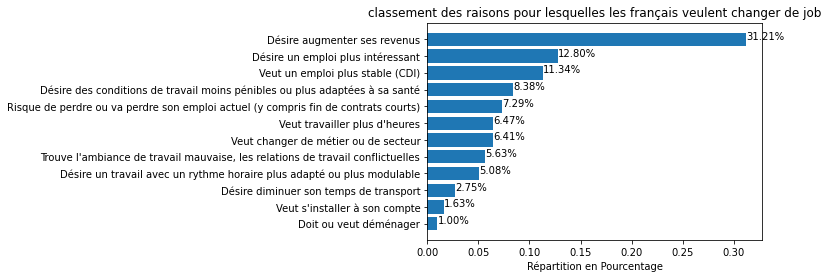

In [29]:
# Créons maintenant le graphique 
plt.title("classement des raisons pour lesquelles les français veulent changer de job")
plt.barh(chart_data.index, repartition)
plt.xlabel("Répartition en Pourcentage")

for i in range(len(repartition)):
    plt.text(repartition[i], chart_data.index[i], f'{repartition[i]:.2%}')
    
plt.show()